# 03_Fast_Modeling_Local.ipynb

## Part 1: Setup and Data Loading
This notebook is designed for local analysis (Jupyter/VSCode) using a relative path to the pre-processed results.

In [6]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import os

# 1. Configuration & Hardcoded Edges
CORE_ASPECTS = [
    'ingredients', 'packaging', 'price/value', 'service/shipping',
    'smell/fragrance', 'effectiveness/results', 'texture/consistency'
]

NAME_MAP = {
    'ingredients': 'ingredients',
    'packaging': 'packaging',
    'price/value': 'price_value',
    'service/shipping': 'service_shipping',
    'smell/fragrance': 'smell_fragrance',
    'effectiveness/results': 'effectiveness_results',
    'texture/consistency': 'texture_consistency'
}

GLASSO_EDGES = [
    ('smell_fragrance', 'texture_consistency'), ('smell_fragrance', 'packaging'),
    ('smell_fragrance', 'ingredients'), ('price_value', 'packaging'),
    ('price_value', 'ingredients'), ('price_value', 'effectiveness_results'),
    ('price_value', 'service_shipping'), ('texture_consistency', 'packaging'),
    ('texture_consistency', 'ingredients'), ('texture_consistency', 'effectiveness_results'),
    ('packaging', 'ingredients'), ('packaging', 'effectiveness_results'),
    ('packaging', 'service_shipping'), ('ingredients', 'effectiveness_results'),
    ('ingredients', 'service_shipping')
]

# 2. Load Local Data
data_path = '../data/Seminar_Amazon_Results_FULL.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Local data loaded: {len(df)} rows.")
else:
    print(f"❌ Error: File not found at {data_path}. Please ensure the CSV is in the './data/' folder.")

✅ Local data loaded: 701528 rows.


## Part 2: Critical Data Parsing and Pivoting

In [7]:
def process_saved_results(df):
    """Parses stringified lists, pivots, and mean-centers features."""
    
    # 1. CRITICAL: Parse stringified lists of tuples
    print("Parsing aspect_sentiments column...")
    df['aspect_sentiments'] = df['aspect_sentiments'].apply(ast.literal_eval)
    
    # 2. Pivot
    print("Pivoting and averaging duplicate mentions...")
    exploded = df[['aspect_sentiments']].explode('aspect_sentiments')
    exploded = exploded.dropna(subset=['aspect_sentiments'])
    aspect_sent = pd.DataFrame(exploded['aspect_sentiments'].tolist(), index=exploded.index)
    aspect_sent.columns = ['aspect', 'sentiment']
    
    # Group by index and aspect, take the MEAN of sentiments (as requested)
    pivoted = aspect_sent.groupby([aspect_sent.index, 'aspect'])['sentiment'].mean().unstack(fill_value=0.0)
    
    # 3. Rename and Ensure all aspects are present
    final_aspects = []
    for raw_name in CORE_ASPECTS:
        clean_name = NAME_MAP.get(raw_name, raw_name.replace('/', '_').replace(' ', '_'))
        if raw_name in pivoted.columns:
            pivoted = pivoted.rename(columns={raw_name: clean_name})
        else:
            if clean_name not in pivoted.columns:
                pivoted[clean_name] = 0.0
        final_aspects.append(clean_name)
    
    # 4. Merge with original data for rating
    data = pivoted.join(df[['rating']])
    data = data.dropna(subset=['rating'])
    
    # 5. Sparsity filter
    data = data[(data[final_aspects] != 0).any(axis=1)].copy()
    
    # 6. Mean centering
    print("Mean-centering features...")
    for col in final_aspects:
        data[col] = data[col] - data[col].mean()
        
    return data, final_aspects

model_data, base_features = process_saved_results(df)

Parsing aspect_sentiments column...
Pivoting and averaging duplicate mentions...
Mean-centering features...


## Part 3: Statistical Modeling and Evaluation


SCIENTIFIC MODEL COMPARISON

BASELINE:
R2: 0.3353 | Adj R2: 0.3353 | BIC: 1039391.31
Coefficients:
Intercept                3.940040
ingredients              1.224358
packaging                1.107022
smell_fragrance          0.991980
price_value              0.973841
effectiveness_results    0.824851
service_shipping         0.693342
texture_consistency      0.679003
dtype: float64

GLASSO NETWORK:
R2: 0.3497 | Adj R2: 0.3496 | BIC: 1032536.33
Coefficients:
Intercept                                    3.968649
ingredients                                  1.140966
packaging                                    1.027000
smell_fragrance                              0.965452
price_value                                  0.958279
effectiveness_results                        0.838350
service_shipping                             0.717422
texture_consistency                          0.696430
packaging:service_shipping                  -0.379144
texture_consistency:packaging               -0.392

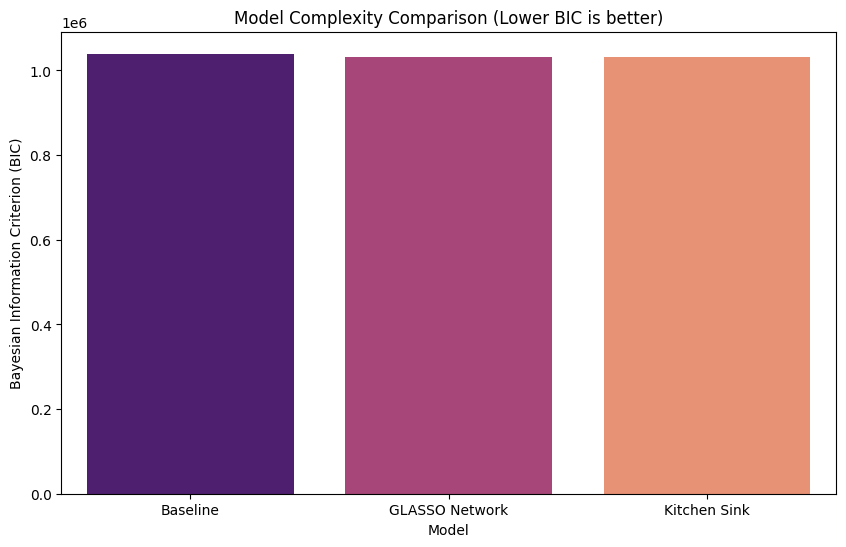

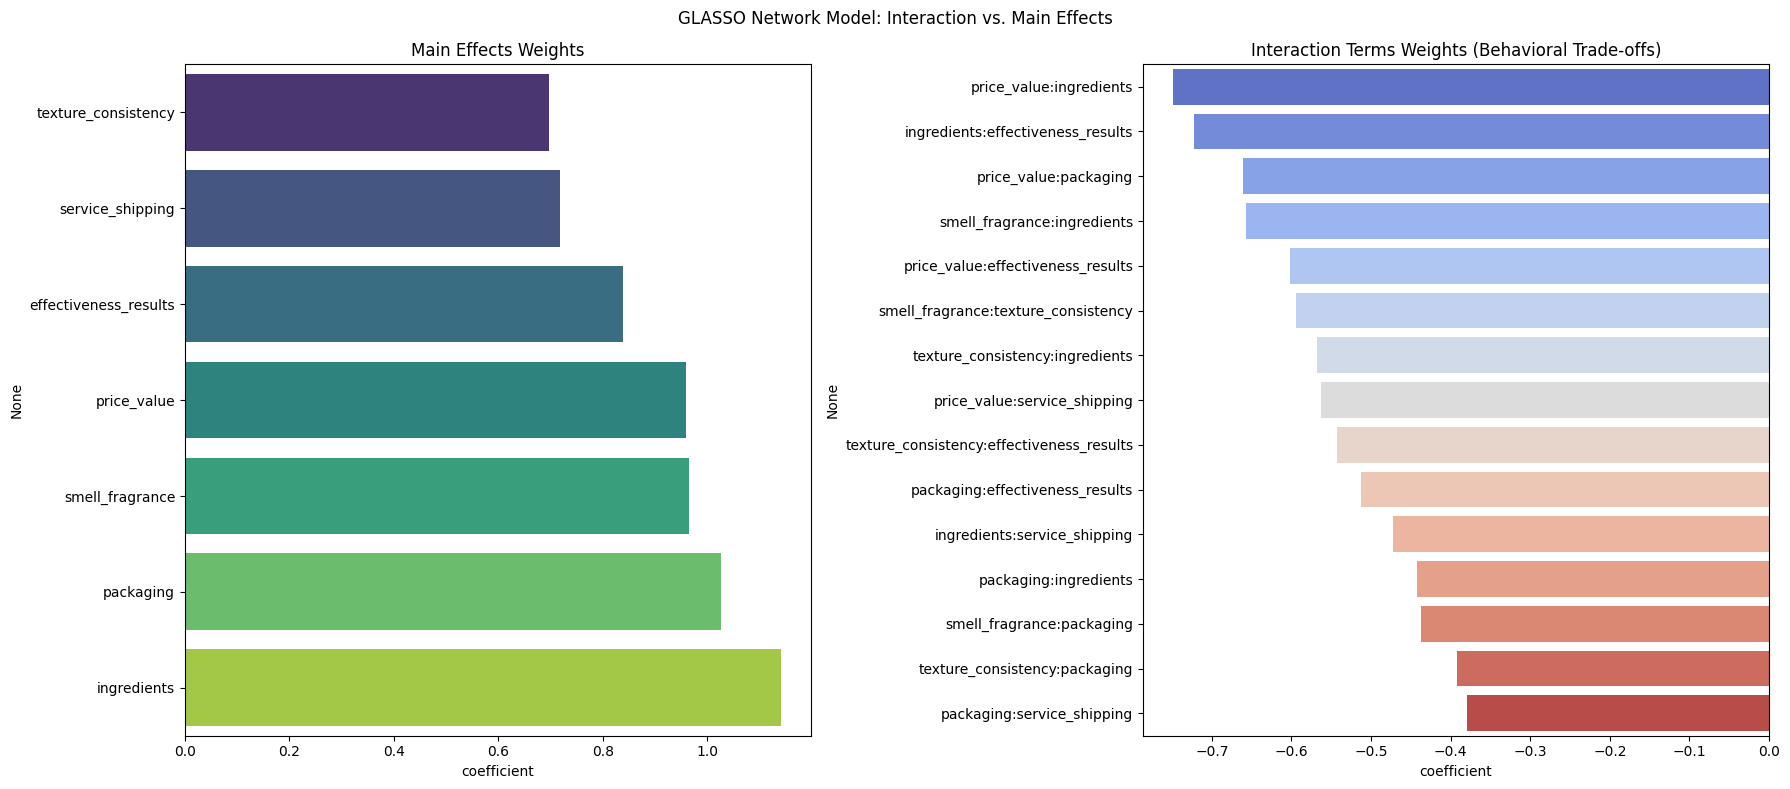

In [8]:
# 1. Define Formulas
baseline_formula = "rating ~ " + " + ".join(base_features)

glasso_interactions = [f"{u} * {v}" for u, v in GLASSO_EDGES]
glasso_formula = "rating ~ " + " + ".join(base_features) + " + " + " + ".join(glasso_interactions)

all_interactions = []
for i in range(len(base_features)):
    for j in range(i + 1, len(base_features)):
        all_interactions.append(f"{base_features[i]} * {base_features[j]}")
kitchen_sink_formula = "rating ~ " + " + ".join(base_features) + " + " + " + ".join(all_interactions)

# 2. Fit Models
model_baseline = smf.ols(baseline_formula, data=model_data).fit()
model_glasso = smf.ols(glasso_formula, data=model_data).fit()
model_kitchen = smf.ols(kitchen_sink_formula, data=model_data).fit()

# 3. Scientific Comparison
print("\n" + "="*50)
print("SCIENTIFIC MODEL COMPARISON")
print("="*50)
models = [('Baseline', model_baseline), ('GLASSO Network', model_glasso), ('Kitchen Sink', model_kitchen)]
results = []
for name, model in models:
    results.append({
        'Model': name,
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj,
        'BIC': model.bic,
        'Params': len(model.params)
    })
    print(f"\n{name.upper()}:")
    print(f"R2: {model.rsquared:.4f} | Adj R2: {model.rsquared_adj:.4f} | BIC: {model.bic:.2f}")
    print("Coefficients:")
    print(model.params[model.params != 0].sort_values(ascending=False))

# 4. Visualization
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='BIC', data=results_df, palette='magma', hue='Model', legend=False)
plt.title('Model Complexity Comparison (Lower BIC is better)')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.show()

# Coefficients Plot for GLASSO Model
coef_df = model_glasso.params.drop('Intercept')
interactions = coef_df[coef_df.index.str.contains(':')].sort_values().to_frame('coefficient')
main_effects = coef_df[~coef_df.index.str.contains(':')].sort_values().to_frame('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Main Effects
if not main_effects.empty:
    sns.barplot(x='coefficient', y=main_effects.index, data=main_effects, palette='viridis', hue=main_effects.index, legend=False, ax=axes[0])
axes[0].set_title('Main Effects Weights')

# Interaction Terms
if not interactions.empty:
    sns.barplot(x='coefficient', y=interactions.index, data=interactions, palette='coolwarm', hue=interactions.index, legend=False, ax=axes[1])
else:
    axes[1].text(0.5, 0.5, 'No Interaction Terms Found', ha='center', va='center')
axes[1].set_title('Interaction Terms Weights (Behavioral Trade-offs)')

plt.suptitle('GLASSO Network Model: Interaction vs. Main Effects')
plt.tight_layout()
plt.show()